<a href="https://colab.research.google.com/github/ODBapp/2025_NODASS_workshop/blob/main/src/odb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/ODBapp/2025_NODASS_workshop.git

Cloning into '2025_NODASS_workshop'...
remote: Enumerating objects: 221, done.
remote: Counting objects: 100% (221/221), done.
remote: Compressing objects: 100% (203/203), done.
remote: Total 221 (delta 59), reused 52 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (221/221), 109.15 MiB | 15.04 MiB/s, done.
Resolving deltas: 100% (59/59), done.


# 地理資訊

In [ ]:
%cd /content/2025_NODASS_workshop/src/geo

In [ ]:
import csv, json
import xml.etree.ElementTree as ET

In [ ]:
# === 轉換時間為ISO8601 ===
def toISO8601(datetime_string):
    return datetime_string.strip().replace('/', '-').replace(' ', 'T')

In [ ]:
# === GeoJSON輸出 ===
def export_geojson(out_path, coords, pt_properties=None, line=True, line_properties=None):
    pt_properties = pt_properties or []
    line_properties = line_properties or {}

    features = []
    for idx, coord in enumerate(coords):
        props = pt_properties[idx] if idx < len(pt_properties) else {}
        features.append({
            "type": "Feature",
            "geometry": {"type": "Point", "coordinates": coord},
            "properties": props
        })

    if line:
        features.append({
            "type": "Feature",
            "geometry": {
                "type": "LineString",
                "coordinates": coords
            },
            "properties": line_properties
        })

    geojson = {
        "type": "FeatureCollection",
        "features": features
    }
    with open(out_path, 'w', encoding='utf-8') as f:
        # json.dump(geojson, f) # 無排版，檔案較小(15KB)
        json.dump(geojson, f, indent=2) # 排版，檔案較大 (30KB)

In [ ]:
# === KML輸出 ===
def export_kml(out_path, coords, pt_descriptions=None, pt_names=None, line=True, line_properties=None, line_name='線段'):
    pt_descriptions = pt_descriptions or []
    pt_names = pt_names or []
    line_properties = line_properties or {}

    kml = ET.Element("kml", xmlns="http://www.opengis.net/kml/2.2")
    document = ET.SubElement(kml, "Document")

    names = pt_names
    if len(coords) > len(names):
        names = [str(i + 1) for i in range(len(coords))]

    for idx, coord in enumerate(coords):
        placemark = ET.SubElement(document, "Placemark")
        ET.SubElement(placemark, "name").text = names[idx]
        if idx < len(pt_descriptions):
            ET.SubElement(placemark, "description").text = pt_descriptions[idx]

        point = ET.SubElement(placemark, "Point")
        ET.SubElement(point, "coordinates").text = f"{coord[0]},{coord[1]}"

    if line:
        placemark = ET.SubElement(document, "Placemark")
        ET.SubElement(placemark, "name").text = line_name
        ET.SubElement(placemark, "description").text = line_properties

        linestring = ET.SubElement(placemark, "LineString")
        ET.SubElement(linestring, "tessellate").text = "1"
        coords_text = ' '.join(f"{coord[0]},{coord[1]}" for coord in coords)
        ET.SubElement(linestring, "coordinates").text = coords_text

    ET.indent(kml, space="  ") # 排版方便閱讀，但檔案大小增加 (17KB vs 22KB)
    ET.ElementTree(kml).write(out_path, encoding='utf-8-sig', xml_declaration=True)

In [ ]:
# === 路徑檔名設定 ===
csv_path = '202507021522_export_GDP_22943_result.csv'
geojson_path = 'output.json'
kml_path = 'output.kml'

# === 讀取CSV ===
coords = []
times = []
json_pt_properties = []
kml_descriptions = []
total_sst = 0.0
count = 0

with open(csv_path, newline='', encoding='utf-8') as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        try:
            lon = float(row['CenterLongitude'])
            lat = float(row['CenterLatitude'])
            time = toISO8601(row['time'])
            sst = float(row['sst'])

            coords.append([lon, lat])
            times.append(time)
            json_pt_properties.append({"time": time, "sst": sst})
            kml_descriptions.append(f"SST: {sst}<br/>lon: {lon}<br/>lat: {lat}")

            total_sst += sst
            count += 1
        except (ValueError, KeyError):
            continue

In [ ]:
# 加入線段資料
mean_sst = round(10* total_sst / count) / 10

json_ln_properties = {
    "start": times[0],
    "end": times[-1],
    "sst_avg": mean_sst
}
kml_ln_properties = (
    f"Start: {times[0]}<br/>"
    f"End: {times[-1]}<br/>"
    f"Mean SST: {mean_sst}"
)

In [ ]:
# 輸出
export_geojson(geojson_path, coords, json_pt_properties, True, json_ln_properties)
export_kml(kml_path, coords, kml_descriptions, [], True, kml_ln_properties, 'GDP軌跡')

# 生物資料

In [2]:
%cd /content/2025_NODASS_workshop/src/bio

/content/2025_NODASS_workshop/src/bio


In [1]:
# !pip install pandas plotly
import pandas as pd
import re
from datetime import datetime
import plotly.express as px
import plotly.io as pio

### 讀取資料

In [3]:
# NODASS

# handling broken csv file
input_file = 'biodata_NODASS_deepfish_raw.csv'
output_file = 'biodata_NODASS_deepfish_fixing.csv'

with open(input_file, 'r', encoding='utf-8') as fin, \
     open(output_file, 'w', encoding='utf-8') as fout:

    # read header
    header = fin.readline()
    fout.write(header)

    # process by row
    for line in fin:
        # find the 7th comma
        comma_positions = []
        for i, ch in enumerate(line):
            if ch == ',':
                comma_positions.append(i)
                if len(comma_positions) == 9:  # stop at the 9th comma
                    break

        # get the 7th, 8th, 9th comma position
        pos7 = comma_positions[6]
        pos8 = comma_positions[7]
        pos9 = comma_positions[8]

        # check whether "ScientificNameAuthorship" is empty
        if pos8 == pos7 + 1: # Yes: skip this row
            fout.write(line)
        else: # No: wrap ScientificNameAuthorship content by ""
            middle = line[pos7+1:pos9]
            fixed_middle = f'"{middle}"'
            fixed_line = line[:pos7+1] + fixed_middle + line[pos9:]
            fout.write(fixed_line)

# check output file: "biodata_NODASS_deepfish_fixing.csv" >> there are still some exception rows, fix them manually as the file "biodata_NODASS_deepfish.csv"

# read the finalized file
nodass = pd.read_csv('biodata_NODASS_deepfish.csv', encoding='utf-8', quotechar='"')
nodass.head()

,GeoProductID,Id,ProjectID,ProjectName,Organizer,ScientificName,ChineseName,ScientificNameAuthorship,ChineseCommonName,EnglishCommonName,...,FillingDate,UpdatedDate,Remarks,DNA,ExtendColumn,StationID,geom,Project,ProjectUnit,MetaDataID
0,188063,1W-0413Z,FA_DS,台灣深海魚類多樣性的調查研究,TaiBIF,Acanthonus armatus,大棘鼬鳚,"Günther,1878",大棘鼬鳚,NaN,...,2006/8/25,2014/8/26 14:38,邵廣昭 先生 (已退休),NaN,"{""id"":""urn:lsid:deepsea.biodiv.tw:observation:...",NaN,"{""type"":""Point"";""coordinates"":[122.07;24.31]}","{""Title"":""台灣深海魚類多樣性的調查研究"";""Organizer"":""TaiBIF""}",TaiBIF,NaN
1,188064,1W-04140,FA_DS,台灣深海魚類多樣性的調查研究,TaiBIF,Acanthonus armatus,大棘鼬鳚,"Günther,1878",大棘鼬鳚,NaN,...,2002/8/26,2014/8/26 14:38,邵廣昭 先生 (已退休),NaN,"{""id"":""urn:lsid:deepsea.biodiv.tw:observation:...",NaN,"{""type"":""Point"";""coordinates"":[119.46;21.85]}","{""Title"":""台灣深海魚類多樣性的調查研究"";""Organizer"":""TaiBIF""}",TaiBIF,NaN
2,188065,1W-04141,FA_DS,台灣深海魚類多樣性的調查研究,TaiBIF,Acanthonus armatus,大棘鼬鳚,"Günther,1878",大棘鼬鳚,NaN,...,2006/8/25,2014/8/26 14:38,邵廣昭 先生 (已退休),NaN,"{""id"":""urn:lsid:deepsea.biodiv.tw:observation:...",NaN,"{""type"":""Point"";""coordinates"":[122.07;24.31]}","{""Title"":""台灣深海魚類多樣性的調查研究"";""Organizer"":""TaiBIF""}",TaiBIF,NaN
3,188066,1W-04142,FA_DS,台灣深海魚類多樣性的調查研究,TaiBIF,Acanthonus armatus,大棘鼬鳚,"Günther,1878",大棘鼬鳚,NaN,...,2005/6/16,2014/8/26 14:38,邵廣昭 先生 (已退休),NaN,"{""id"":""urn:lsid:deepsea.biodiv.tw:observation:...",NaN,"{""type"":""Point"";""coordinates"":[122.19;24.26]}","{""Title"":""台灣深海魚類多樣性的調查研究"";""Organizer"":""TaiBIF""}",TaiBIF,NaN
4,188067,1W-04143,FA_DS,台灣深海魚類多樣性的調查研究,TaiBIF,Acanthonus armatus,大棘鼬鳚,"Günther,1878",大棘鼬鳚,NaN,...,2006/8/26,2014/8/26 14:38,邵廣昭 先生 (已退休),NaN,"{""id"":""urn:lsid:deepsea.biodiv.tw:observation:...",NaN,"{""type"":""Point"";""coordinates"":[122.07;24.32]}","{""Title"":""台灣深海魚類多樣性的調查研究"";""Organizer"":""TaiBIF""}",TaiBIF,NaN


In [4]:
# ODB
odb = pd.read_csv('biodata_ODB_deepfish.csv')
odb.head()

,出現紀錄識別碼,階層,學名,中文名,緯度,經度,採樣日期,資料主題,資料來源,引用資訊
0,ODB:bio:occ:155684,species,Narke japonica,日本單鰭電鱝,24.455,118.52833,2021-08-15,Demersal Fish,Theses and Dissertations,馬暐承（2023）。2021年夏季金門沿海底棲軟骨魚類群聚結構分析與鱝總目優勢物種生活史特徵...
1,ODB:bio:occ:155682,species,Hemitrygon navarrae,奈氏魟,24.455,118.52833,2021-08-15,Demersal Fish,Theses and Dissertations,馬暐承（2023）。2021年夏季金門沿海底棲軟骨魚類群聚結構分析與鱝總目優勢物種生活史特徵...
2,ODB:bio:occ:155683,species,Narke japonica,日本單鰭電鱝,24.455,118.52833,2021-08-15,Demersal Fish,Theses and Dissertations,馬暐承（2023）。2021年夏季金門沿海底棲軟骨魚類群聚結構分析與鱝總目優勢物種生活史特徵...
3,ODB:bio:occ:155685,species,Okamejei hollandi,何氏甕鰩,24.455,118.52833,2021-08-15,Demersal Fish,Theses and Dissertations,馬暐承（2023）。2021年夏季金門沿海底棲軟骨魚類群聚結構分析與鱝總目優勢物種生活史特徵...
4,ODB:bio:occ:155691,species,Scoliodon laticaudus,寬尾斜齒鯊,24.455,118.52833,2021-08-15,Demersal Fish,Theses and Dissertations,馬暐承（2023）。2021年夏季金門沿海底棲軟骨魚類群聚結構分析與鱝總目優勢物種生活史特徵...


### 欄位內容檢查

In [5]:
# column inspect function
def column_inspector(df, col_name, max_unique=10, print_type=0):
    print(f"\n[{col_name}]")

    # data type
    dtype = df[col_name].dtype
    print(f"Data Type: {dtype}\n")

    # numeric or other data
    if pd.api.types.is_numeric_dtype(df[col_name]):
        print(f"Maximum: {df[col_name].max()}")
        print(f"Minimum: {df[col_name].min()}")
    else:
        unique_vals = df[col_name].dropna().unique()
        total_unique = len(unique_vals)
        limited_vals = unique_vals[:max_unique]
        joined_vals = ', '.join(map(str, limited_vals))
        print(f"Unique Values (showing up to {max_unique} of {total_unique}):")
        if print_type == 0:
            joined_vals = ', '.join(map(str, limited_vals))
            print(joined_vals)
        else:
            for val in limited_vals:
                print(str(val))
        if total_unique > max_unique:
            print(f"...(and {total_unique - max_unique} more)")

    # check for NA or empty value ('')
    is_na = df[col_name].isna().sum()
    is_empty = (df[col_name] == '').sum()
    print(f"\nisNA: {is_na}")
    print(f"isEmpty: {is_empty}")

# apply function
column_inspector(nodass, 'CenterLatitude', 20) # numeric column
column_inspector(nodass, 'ChineseName', 20) # other column


[CenterLatitude]
Data Type: float64

Maximum: 25.38
Minimum: 20.64

isNA: 0
isEmpty: 0

[ChineseName]
Data Type: object

Unique Values (showing up to 20 of 366):
大棘鼬鳚, 大吻狡鼬鳚, 異鱗海蜴魚, 裸頭海蜴魚, Aldrovandia sp., 雙色黑頭魚, 長鰭黑頭魚, 歐氏黑頭魚, Alepocephalus sp., 尖吻黑頭魚, 細鱗擬深海鱈, 澳洲裸鼬魚, 日本篦鯊, 廣吻篦鯊, 扁吻篦鯊, 棘銀斧魚, 長銀斧魚, 巨銀斧魚, 半裸銀斧魚, Argyropelecus sp.
...(and 346 more)

isNA: 0
isEmpty: 0


In [ ]:
# inspect all columns through loop
# for col in nodass.columns:
#     column_inspector(nodass, col, max_unique=10)

### 資料清理

In [6]:
# Sampling Time
def time_handler(df, raw_date_col):
    # parse date
    df['date_parsed'] = pd.to_datetime(df[raw_date_col], errors='coerce')
    df['date'] = df['date_parsed'].dt.strftime('%Y-%m-%d')
    df['year'] = df['date_parsed'].dt.year
    df['month'] = df['date_parsed'].dt.month
    df['day'] = df['date_parsed'].dt.day
    # define season
    def get_season(month):
        if month in [12, 1, 2]:
            return 'winter'
        elif month in [3, 4, 5]:
            return 'spring'
        elif month in [6, 7, 8]:
            return 'summer'
        elif month in [9, 10, 11]:
            return 'fall'
        else:
            return 'unknown'
    df['season'] = df['month'].apply(get_season)
    # drop column date_parsed
    df.drop(columns=['date_parsed'], inplace=True)
    return df

# apply fucntion
nodass = time_handler(nodass, 'FillingDate')
odb = time_handler(odb, '採樣日期')
nodass[['FillingDate','date','year','month','day','season']].head()
odb[['採樣日期','date','year','month','day','season']].head()

,採樣日期,date,year,month,day,season
0,2021-08-15,2021-08-15,2021,8,15,summer
1,2021-08-15,2021-08-15,2021,8,15,summer
2,2021-08-15,2021-08-15,2021,8,15,summer
3,2021-08-15,2021-08-15,2021,8,15,summer
4,2021-08-15,2021-08-15,2021,8,15,summer


In [7]:
# Sampling Protocol
nodass['gearType'] = nodass['SamplingProtocol'].apply(
    lambda x: 'beam_trawl' if isinstance(x, str) and 'beam trawl' in x.lower()
    else x.lower().replace(' ', '_') if isinstance(x, str)
    else x
)

# check result
column_inspector(nodass, 'gearType')


[gearType]
Data Type: object

Unique Values (showing up to 10 of 4):
beam_trawl, otter_trawl, ikmt, dredge

isNA: 179
isEmpty: 0


In [8]:
# Organism Quantity
nodass.sort_values(by=['FillingDate','CenterLongitude', 'CenterLatitude','SamplingProtocol','ScientificName'], ascending=True, inplace=True)
nodass[['CenterLatitude','CenterLongitude','FillingDate','SamplingProtocol','ScientificName','IndividualCount']].head(15)
# >> no sampling effort & eventID information, hard to quantify... remember to 'unique' before analyze

,CenterLatitude,CenterLongitude,FillingDate,SamplingProtocol,ScientificName,IndividualCount
274,22.34,120.11,2001/11/21,Otter trawl,Bathypterois guentheri,1
333,22.34,120.11,2001/11/21,Otter trawl,Bothus myriaster,1
1527,22.34,120.11,2001/11/21,Otter trawl,Gen. sp(Sternoptychidae),1
1734,22.34,120.11,2001/11/21,Otter trawl,Hoplostethus melanopus,1
1870,22.34,120.11,2001/11/21,Otter trawl,Lamprogrammus brunswigi,1
1927,22.34,120.11,2001/11/21,Otter trawl,Melanostomiidae sp.,1
1955,22.34,120.11,2001/11/21,Otter trawl,Monomitopus kumae,1
1970,22.34,120.11,2001/11/21,Otter trawl,Monomitopus kumae,1
2024,22.34,120.11,2001/11/21,Otter trawl,Nemichthys sp.,1
2073,22.34,120.11,2001/11/21,Otter trawl,Neobythites sp.,1


### 學名校對

In [9]:
# check pattern
# column_inspector(nodass,'ScientificName',367,1)

# parse function
def taxon_info_handler(df):
    def taxon_parser(name):
         # Case 1 (genus): "XXX sp."
        if re.match(r'^[A-Z][a-zA-Z_-]*\s+sp\.?$', name):
            parsed_taoxn = name.split()[0]
            return pd.Series(['genus', parsed_taoxn])
        # Case 2 (genus): "Gen. sp(XXX)"
        match = re.search(r'sp\(?([A-Z][a-zA-Z_-]*)\)?', name)
        if match:
            return pd.Series(['genus', match.group(1)])
        # Others (species)
        return pd.Series(['species', name])
    df[['taxonRank', 'taxon']] = df['ScientificName'].apply(taxon_parser)
    return df

nodass = taxon_info_handler(nodass)
taxon_pairs = nodass[['taxonRank','taxon']].drop_duplicates()

# check result
# with pd.option_context('display.max_rows', None):
#     print(taxon_pairs)

In [11]:
# get all parsed names
# for name in taxon_pairs['taxon']:
#     print(name)

# use external tool: TaiBIF NomenMatch (https://match.taibif.tw/v2/index.html)
# >> copy-paste result to NomenMatch
# >> check the result.csv file

In [13]:
# merge matched table
taxon_matched = pd.read_csv('nomenmatch_results.csv')
nodass_merge = pd.merge(nodass, taxon_matched[["search_term",'matched_clean','match_type']], left_on='taxon', right_on='search_term', how='left')

# get all species data
nodass_species = nodass_merge.query("taxonRank == 'species' & match_type != 'No match'" )
odb_species = odb.query("階層 == 'species'" )

### 資料串接

In [14]:
# rename columns (DwC standard)
nodass_species = nodass_species.rename(columns={
    'Id': 'occurrenceID',
    'matched_clean': 'scientificName',
    'ChineseName': 'chineseName',
    'CenterLatitude': 'decimalLatitude',
    'CenterLongitude': 'decimalLongitude',
    'date': 'eventDate',
    'gearType': 'samplingProtocol',
    'IndividualCount': 'individualCount',
    'ProjectName': 'dataSource'
})
odb_species = odb_species.rename(columns={
    '出現紀錄識別碼': 'occurrenceID',
    '學名': 'scientificName',
    '中文名': 'chineseName',
    '緯度': 'decimalLatitude',
    '經度': 'decimalLongitude',
    '引用資訊': 'dataSource',
    'date': 'eventDate'
})

# select columns
nodass_trim = nodass_species[['occurrenceID','scientificName','chineseName','decimalLatitude','decimalLongitude','eventDate','year','season','samplingProtocol','dataSource']]
odb_trim = odb_species[['occurrenceID','scientificName','chineseName','decimalLatitude','decimalLongitude','eventDate','year','season','dataSource']]

# data concat & remove duplicate
biodata = pd.concat([nodass_trim, odb_trim], ignore_index=True).drop_duplicates()
biodata.head()

,occurrenceID,scientificName,chineseName,decimalLatitude,decimalLongitude,eventDate,year,season,samplingProtocol,dataSource
0,1W-041BL,Bathypterois guentheri,貢氏深海狗母魚,22.34,120.11,2001-11-21,2001,fall,otter_trawl,台灣深海魚類多樣性的調查研究
1,1W-041D8,Bothus myriaster,繁星鮃,22.34,120.11,2001-11-21,2001,fall,otter_trawl,台灣深海魚類多樣性的調查研究
2,1W-042G5,Hoplostethus melanopus,黑首胸燧鯛,22.34,120.11,2001-11-21,2001,fall,otter_trawl,台灣深海魚類多樣性的調查研究
3,1W-042JX,Lamprogrammus brunswigi,布氏軟鼬鳚,22.34,120.11,2001-11-21,2001,fall,otter_trawl,台灣深海魚類多樣性的調查研究
4,1W-042MA,Monomitopus kumae,熊吉單趾鼬鳚,22.34,120.11,2001-11-21,2001,fall,otter_trawl,台灣深海魚類多樣性的調查研究


In [15]:
# check output again
# for col in biodata.columns:
#     column_inspector(biodata, col, max_unique=20)

# save combined file
today = datetime.today().date()
biodata.to_csv(f'biodata_{today}.csv', index=False, encoding='utf-8-sig')

### 資料使用限制與注意事項

In [ ]:
# biodata = pd.read_csv('biodata_XXXX-XX-XX.csv')

In [16]:
# species in year (ignore differences in sampling effort)

# count species N by year
species_per_year = biodata.groupby('year')['scientificName'].nunique().reset_index()

# plot
fig = px.bar(species_per_year, x='year', y='scientificName',
             labels={'scientificName': '物種數', 'year': '年份'},
             title='每年出現物種數',
             text='scientificName')
fig.update_traces(textposition='outside')
fig.update_layout(yaxis_title='物種數', xaxis_title='年份')
fig.show()

In [17]:
# species in season (ignore differences in sampling effort)

# count species N by season
season_order = ['spring', 'summer', 'fall', 'winter']
season_species = biodata.groupby('season')['scientificName'].nunique().reindex(season_order).reset_index()

# plot
fig = px.bar(season_species, x='season', y='scientificName',
             color='season',
             labels={'scientificName': '物種數', 'season': '季節'},
             title='各季出現物種數')
fig.show()

In [18]:
# event in season-year

# define eventID
biodata['eventID'] = biodata.groupby(['decimalLatitude', 'decimalLongitude', 'eventDate']) \
                  .ngroup() \
                  .apply(lambda x: f"ev_{x:05d}")
# count species N by eventID
event_info = biodata[['eventID', 'year', 'season']].drop_duplicates()
sampling_counts = event_info.groupby(['year', 'season']).size().reset_index(name='sampling_count')

# plot
fig = px.bar(sampling_counts,
             x='year',
             y='sampling_count',
             color='season',
             barmode='stack',
             category_orders={'season': ['spring', 'summer', 'fall', 'winter']},
             labels={'year': '年份', 'sampling_count': '採樣次數', 'season': '季節'},
             title='每年每季採樣次數')
fig.show()

In [19]:
# sampling protocol

# filtered data: 4 cast from 2001-summer around Northeastern of Taiwan
filtered_data = biodata[
    (biodata['decimalLongitude'] >= 121.5) & (biodata['decimalLongitude'] <= 122.2) &
    (biodata['decimalLatitude'] >= 24.5) & (biodata['decimalLatitude'] <= 25.5) &
    (biodata['year'] == 2001) & (biodata['season'] == 'summer')
]

method_species = (
    filtered_data[['samplingProtocol', 'scientificName']]
    .drop_duplicates()
    .groupby('samplingProtocol')['scientificName']
    .apply(lambda x: sorted(x.unique()))
)

for method, species_list in method_species.items():
    print(f"\nGear Type：{method}")
    for sp in species_list:
        print(f" - {sp}")


Gear Type：beam_trawl
 - Alepocephalus bicolor
 - Chimaera phantasma
 - Chlorophthalmus nigromarginatus
 - Dentex tumifrons
 - Diaphus garmani
 - Diaphus signatus
 - Erisphex pottii
 - Gavialiceps taiwanensis
 - Gonorynchus abbreviatus
 - Lepidotrigla hime
 - Symphurus strictus
 - Ventrifossa garmani
 - Xenodermichthys nodulosus

Gear Type：otter_trawl
 - Alepocephalus bicolor
 - Bathycongrus wallacei
 - Benthosema pterotum
 - Chimaera phantasma
 - Deania calcea
 - Diaphus garmani
 - Diaphus suborbitalis
 - Etmopterus lucifer
 - Gadella jordani
 - Gavialiceps taiwanensis
 - Harpadon microchir
 - Helicolenus hilgendorfii
 - Homostolus acer
 - Monomitopus kumae
 - Neobythites stigmosus
 - Photonectes albipennis
 - Polyipnus stereope
 - Polyipnus triphanos
 - Setarches longimanus
 - Symphurus orientalis


# 海洋熱浪

In [ ]:
%cd /content/2025_NODASS_workshop/src/mhw

In [ ]:
# 全球海洋熱浪資料計算
from datetime import datetime # https://docs.python.org/3/library/datetime.html # 時間格式與處理
import xarray # https://docs.xarray.dev/en/stable/ # for processing .nc files
import numpy as np # https://numpy.org/ # 處理list
import pandas as pd # https://pandas.pydata.org/ # 資料讀取分析
import requests #https://requests.readthedocs.io/en/latest/ # 下載資料
#import wget # https://www.gnu.org/software/wget/ # 下載資料
import re # https://docs.python.org/3/library/re.html # 正規表達式
import os # https://docs.python.org/3/library/os.html # 處理檔案與路徑等
import matplotlib.pyplot as plt # https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.html # 畫圖

In [ ]:
# === step 0: 取得海溫資料 (從 NOAA 下載每日資料 nc 檔) ===

# 此範例是一次下載一個月的資料

# 我選擇時間的邏輯是當下時間的前一個月
#now = datetime.now()
#month_now = int(now.strftime('%m'))
#year_now = int(now.strftime('%Y'))
#if (month_now > 1):
#    month_now = str(month_now - 1).zfill(2) # 個位數的話補0(ex.2，補零，變成02)
#else:
#    year_now =year_now -1 # 如果是 1 月，想下載的資料會是，去年的 12 月
#    month_now = '12'

# NOAA的檔案網址
#url =f'https://www.ncei.noaa.gov/data/sea-surface-temperature-optimum-interpolation/v2.1/access/avhrr/{year_now}{month_now}/'

# 設定路徑
# 若你是在自己電腦而非在colab，特別是在 Windows 要改變路徑的寫法
#working_dir = "/home/yeh/thermal/"

# 你存每日.nc檔的地方
#OISST_dir = os.path.join(working_dir, 'OISST/')
#print('開始判斷資料夾')
# 判斷 OISST 這個要存 .nc 檔的資料夾是否存在，若不存在就建一個 OISST 為名的資料夾
#if os.path.exists(OISST_Dir):
#    pass
#    print('資料夾存在')
#else:
#    os.makedirs(OISST_Dir, exist_ok=True)
#
# 檢查 url 這個變數內的網址是否為一個檔案，若是一個檔案就不會以"/"結束
# isFile function
#def isFile(url):
#    if url.endswith('/'):
#        return False
#    else:
#        return True

# 把要下載的 nc file 放在一個 list 內
# get_url function
#def get_url(base_url):
#    text = ''
#    try:
        # html into text
#        text=requests.get(base_url).text
#    except Exception as e:
#        print("error - > ",base_url,e)
#        pass
#    reg = '<a href="(.*?)">.*</a>'
#    urls = [base_url + url for url in re.findall(reg, text) if url != '../']
#    files=[]
#    for i in urls:
#        if i.endswith('nc'):
#            files.append(i)
#    return files

# 下載
# 先檢查url是否為一個檔案(用 function isFile)
# 如果是一個檔案
# 把檔案名字取出
# 檢查此檔案是否已存在資料夾
# 若沒有
# 用 wget 下載
#def get_file(url):
#    if isFile(url):
#        try:
#            full_name = url.split('//')[-1]
#            filename = full_name.split('/')[-1]
#            path_filename = OISST_Dir  + filename
#            if os.path.isfile(path_filename):
#                print(f'{filename} 存在')
#                pass
#            else:
#                wget.download(url,OISST_Dir)
#        except:
#            pass
#    else:
#        urls = get_url(url)
#        for u in urls:
#            get_file(u)

#get_file(url)


In [ ]:
# 說明 xarray 讀取 .nc 檔
ds0 = xarray.open_dataset("./data/oisst-avhrr-v02r01.20250501.nc")
print(ds0) # 印出資料表頭（包含變數、維度、屬性等基本資訊）

# 補充
#print(ds0.attrs) # 印出整份資料的 metadata 屬性

#for key, value in ds0.attrs.items():
#    print(f"{key}: {value}")

#for key, value in ds0['anom'].attrs.items(): # Climatology is based on 1971-2000 OI.v2 SST.
#    print(f"{key}: {value}")

#ds0['ice']

#print(ds0['sst'].shape) # 維度

#print(ds0['sst'].values) # 實際值
#每個list長度是1440


In [ ]:
# === step 1: 計算每個格點每個月的平均海表溫度 (Monthly Mean SST) ===

# 指定要處理的年份
year = '2025'

# 組合該年所有檔案的路徑
file_path = f'./data/*{year}*.nc'

# 開啟多個 NetCDF 檔案並合併為一個資料集（使用 dask 平行處理）
ds = xarray.open_mfdataset(file_path, parallel=True, chunks={'time': '500MB'})

# 對時間進行重取樣（resample）為每月（'1MS' = 每月第一天），並取月平均
mean_month_sst = ds["sst"].resample(time='1MS').mean().compute()

# 清除極值（e.g., 大於 100°C 的值當作錯誤資料）
mean_month_sst = mean_month_sst.where(mean_month_sst <= 100)

# 顯示結果：每個月、每個格點的平均海溫（緯度 x 經度，720 x 1440）
#mean_month_sst
#mean_month_sst.shape

In [ ]:
# === step 2: SST 遮罩 (去除冰區與陸地) ===

# 參數：定義海冰遮罩條件（每月內超過幾天有冰就排除）
ndays_ice = 15
# === (1) 製作海冰遮罩 ===
ice = ds.ice.fillna(0)  # 把 NaN 補成 0，代表該格點當天沒有冰
ice_binary = xarray.where(ice <= 0, 0, 1)  # 有冰（>0%）設為 1，沒冰設為 0
ice_days_per_month = ice_binary.resample(time='1MS').sum(dim='time')  # 統計每個月內冰天數
ice_mask = xarray.where(ice_days_per_month > ndays_ice, 1, 0)  # 若該月冰天數超過 15 天 → 遮罩值設為 1，否則為 0

# === (2) 載入並調整陸地遮罩 ===
lsm = xarray.open_dataset('./data/lsmask.oisst.v2.nc') # NOAA 下載
lsm = -lsm["lsmask"] + 1  # 調整為：0 = 海洋, 1 = 陸地
# 補充排除區域：五大湖與 Lake Ponchartrain
lsm = lsm.where(~((lsm.lon >= 267) & (lsm.lon < 285) & (lsm.lat >= 41) & (lsm.lat <= 50)), 1)
lsm = lsm.where(~((lsm.lon >= 269.5) & (lsm.lon < 270.5) & (lsm.lat >= 30) & (lsm.lat <= 31)), 1)

# === (3) 套用遮罩條件到每月 SST ===
masked_sst = mean_month_sst.copy()  # 複製一份資料用來存結果

for i in range(mean_month_sst.time.size):
    # 取出第 i 個月的 SST 與冰遮罩
    sst_slice = mean_month_sst.isel(time=i)
    ice_slice = ice_mask.isel(time=i)

    # 套用 land mask（lsm == 0 表示海洋）
    temp = sst_slice.where(lsm == 0, np.nan)

    # 套用 ice mask（ice_mask == 0 表示該月沒有冰 ）
    # （符合條件的水域 & 沒有冰）兩者都滿足才保留，否則設為 np.nan
    temp = temp.where(ice_slice == 0, np.nan)

    temp = temp.squeeze(drop=True)  # 移除多餘維度

    # 存回對應時間點的 masked SST
    masked_sst[i, :, :] = temp.values


In [ ]:
# 比較未遮罩 / 已遮罩的 SST 地圖

fig, axes = plt.subplots(1, 2, figsize=(15, 3.5))
cmap = plt.get_cmap('coolwarm')
mean_month_sst.isel(time=0).squeeze().plot(ax=axes[0],cmap=cmap)
axes[0].set_title("original SST")

masked_sst.isel(time=0).squeeze().plot(ax=axes[1],cmap=cmap)
axes[1].set_title("masked SST")

# xarray.plot() 沒有畫真實地圖背景、也沒有地圖投影概念，只是用來「快速預覽資料」
# 只是資料分佈圖

In [ ]:
# === step 3: 計算距平值 (SST Anomaly) ===
# 距平值 = 當月海溫 - 長期氣候平均海溫

# 讀入 1982–2011 的長期氣候平均月海溫（April + May 兩個月的氣候值已經預先儲存）
sst_clim = xarray.open_dataset('./data/oisst_sst_clim_1982-2011_April_May.nc')

# 取出 masked_sst 的時間對應的月份（轉成整數，例如 4, 5）
month_now = pd.to_datetime(masked_sst.time.values).month

# 使用 xarray 的 sel 方法，根據月份挑出對應的氣候平均值，再與當月觀測值相減
sst_an = masked_sst - sst_clim.sel(month=month_now)

# 改名
sst_an = sst_an.rename({'sst': 'sst_an'})

# 顯示資料結構
sst_an


In [ ]:
# 安裝畫地圖用的套件
# https://github.com/SciTools/cartopy
!pip install cartopy

In [ ]:
# 畫距平值地圖
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.font_manager import FontProperties
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 取出一個時間點的資料（假設只處理單月）
# 去除 time, zlev 維度，只留下 (lat, lon)
sst_an_1m = sst_an.sel(time='2025-04-01',month=4).squeeze()["sst_an"]

# 建立圖形
fig = plt.figure(figsize=(10, 4))
ax = plt.axes(projection=ccrs.PlateCarree())


# 畫海溫距平圖
pcm = sst_an_1m.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdYlBu_r',
    vmin=-3,
    vmax=3,
    add_colorbar=False,
    add_labels=False
)

ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '10m',
                                                edgecolor='face',
                                                facecolor='lightgray'))
# 加經緯線
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
gl.right_labels = False
gl.top_labels = False

# 加 colorbar
axins1 = inset_axes(ax, width="100%", height="5%", borderpad=-5, loc='lower center')
cbar = fig.colorbar(pcm, ax=ax,orientation="horizontal",cax=axins1)
cbar.set_label('(°C)')


# 標題
plot_date = pd.to_datetime(sst_an.time.values[0]).strftime('%Y-%m')
ax.set_title(f'Sea Surface Temperature Anomaly: {plot_date}', fontsize=12)

fig.subplots_adjust(bottom=0.15, top=0.9)
plt.show()

In [ ]:
# === step 4: 計算 threshold 閾值 ===
# 每個月使用「滑動三個月視窗」(three months moving window)+ 分位數（如 90th percentile）來定義門檻
# 全部的距平值檔案太大
# 程式參考用
# 讀取距平值資料（1982–2023）
#sst_an_dt = xarray.open_dataset('oisst_an_1982-2023.nodetrend.nc')

# 定義門檻值（百分位數）
#threshold = 0.9

# 選取用來計算 climatology 的期間（1982–2011）
#sst_an_dt_clim = sst_an_dt.sel(time=slice('1982-01-01', '2011-12-31'))

# 自動抓資料變數名稱（通常是 'sst_an'）
#anomaly_var = list(sst_an_dt_clim.data_vars.keys())[0]

# 初始化一個 list 來裝每個月的門檻值
#threshold_by_month_list = []

# 針對每一個月份（1~12）做迴圈
#for month in range(1, 13):
    # 取出該月前後一個月（共三個月）當作背景值
#    prev_month = 12 if month == 1 else month - 1
#    next_month = 1 if month == 12 else month + 1
#    month_window = [prev_month, month, next_month]

    # 選取這三個月的距平值資料
#    monthly_anomalies = sst_an_dt_clim.sel(time=sst_an_dt_clim.time.dt.month.isin(month_window))[anomaly_var]

    # 計算這三個月的第90百分位數（各格點門檻值）
#    threshold_map = monthly_anomalies.quantile(threshold, dim='time', skipna=True)

    # 為這個門檻值地圖標記是哪一個目標月份
#    threshold_map = threshold_map.assign_coords(target_month=month).rename("sst_anomaly_threshold")

    # 收集起來
#    threshold_by_month_list.append(threshold_map)

# 合併所有月份的門檻值（共12個 target_month）
#sst_anomaly_threshold_all_months = xarray.concat(threshold_by_month_list, dim="target_month")

# 儲存為 .nc 檔案（方便後續讀取）
#sst_anomaly_threshold_all_months.load().to_netcdf("oisst_threshold_1982-2023.nodetrend.nc")

In [ ]:
# === step 5: 熱浪分級 ===
## 建立一個新資料集，用來存放熱浪等級（以距平值分類）
sst_an_level = sst_an.copy()
##threshold
sst_an_thr = xarray.open_dataset('./data/oisst_threshold_April_May.nc')
# 針對每一個時間點（每月），進行熱浪強度分類
for idx, time_point in enumerate(sst_an.time.data):
    current_date = pd.to_datetime(time_point)
    current_month = current_date.month  # 抓出是哪一個月

    # 取得該月的 SST 距平值
    sst_anomaly = sst_an.sel(time=time_point)["sst_an"]

    # 取得該月的門檻值（從預先儲存好的資料中抓對應月份的門檻圖）
    threshold_map = sst_an_thr.sel(time2=current_month)["sst_an_thr"]
    threshold_map = threshold_map.squeeze()  # 去除多餘的維度

    # 熱浪等級判斷（邏輯條件）
    is_above_threshold = sst_anomaly > threshold_map
    is_moderate = np.logical_and(is_above_threshold, sst_anomaly / threshold_map < 2)
    is_strong = np.logical_and(sst_anomaly / threshold_map >= 2, sst_anomaly / threshold_map < 3)
    is_severe = np.logical_and(sst_anomaly / threshold_map >= 3, sst_anomaly / threshold_map < 4)
    is_extreme = sst_anomaly / threshold_map >= 4

    # 初始化分級陣列：預設為 0（不是熱浪）
    level_map = xarray.full_like(sst_anomaly, 0)

    # 指定等級
    level_map = level_map.where(~is_moderate, 1)
    level_map = level_map.where(~is_strong, 2)
    level_map = level_map.where(~is_severe, 3)
    level_map = level_map.where(~is_extreme, 4)

    # 存回原始 DataArray
    sst_an_level["sst_an"][idx] = level_map

# 最後將 sst_an 改名為 level（表示熱浪分級結果）
sst_an_level = sst_an_level.rename({"sst_an": "level"})
sst_an_level

In [ ]:
# 畫 level 地圖
sst_an_level_1m = sst_an_level.sel(time='2025-04-01',month=4).squeeze()["level"]

# 建立圖形
fig = plt.figure(figsize=(10, 4))
ax = plt.axes(projection=ccrs.PlateCarree())

# level 顏色 hex
level_colors = ["#ffffff","#f5c268","#ec6b1a","#cb3827","#7f1416"]

pcm = sst_an_level_1m.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=[0,1,2,3,4,5],
    colors=level_colors,
    add_colorbar=False,
    add_labels=False
)

ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '10m',
                                                edgecolor='face',
                                                facecolor='lightgray'))
# 加經緯線
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
gl.right_labels = False
gl.top_labels = False

# 加 colorbar
axins1 = inset_axes(ax, width="100%", height="5%", borderpad=-5, loc='lower center')
cbar = fig.colorbar(pcm, ax=ax,orientation="horizontal",cax=axins1)
cbar.set_ticks([0.5,1.5,2.5,3.5,4.5])
cbar.set_ticklabels(['None','Moderate','Strong','Severe','Extreme'])


# 標題
plot_date = pd.to_datetime(sst_an.time.values[0]).strftime('%Y-%m')
ax.set_title(f'Sea Surface Temperature Anomaly: {plot_date}', fontsize=12)

fig.subplots_adjust(bottom=0.15, top=0.9)
plt.show()

# 時間序列

In [ ]:
!pip install basemap

In [ ]:
%cd /content/2025_NODASS_workshop/src/timeseries

/content/2025_NODASS_workshop/src/timeseries


In [ ]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter
from matplotlib import cm
from mpl_toolkits.basemap import Basemap
import seaborn as sns
from scipy.stats import pearsonr
from statsmodels.tsa.seasonal import STL

import os
#　from pathlib import Path
# os.chdir(Path().resolve())
print(os.getcwd())

/content/2025_NODASS_workshop/src/timeseries


In [ ]:
# Step 1: Open API Fetch
def fetch_mhw_data(lon0, lat0, lon1, lat1, start, end):
    url = f"https://eco.odb.ntu.edu.tw/api/mhw"
    params = {
        "lon0": lon0,
        "lat0": lat0,
        "lon1": lon1,
        "lat1": lat1,
        "start": start,
        "end": end,
        "append": "sst,sst_anomaly,level",
    }
    response = requests.get(url, params=params)
    if response.status_code == 200:
        return pd.DataFrame(response.json())
    else:
        print("Failed to fetch data:", response.text)
        return None

# region for Niño 3.4 (5°N–5°S, 170°W–120°W)
lon0, lon1 = -170, -120
lat0, lat1 = -5, 5
start, end = "2025-05-01", "2025-05-30"
data = fetch_mhw_data(lon0, lat0, lon1, lat1, start, end)
print(data.head())

       lon    lat        date  level        sst  sst_anomaly
0 -169.875 -4.875  2025-05-01      1  29.800001       0.6174
1 -169.625 -4.875  2025-05-01      1  29.786451       0.6125
2 -169.375 -4.875  2025-05-01      1  29.752903       0.5893
3 -169.125 -4.875  2025-05-01      1  29.705482       0.5486
4 -168.875 -4.875  2025-05-01      0  29.651613       0.4963


In [ ]:
# Test a stronger La Niña event
# Plot a wider region, but it across 180°E antimeridian, so we need to split the data fetching
start, end = "2007-12-01", "2007-12-30"
lat0, lat1 = -25, 25
lon0, lon1 = 135, -60  # 180°E to 300°E

# def get_combined_ssta_data():
d1 = fetch_mhw_data(-179.999, lat0, lon1, lat1, start, end)
d2 = fetch_mhw_data(lon0, lat0, 179.999, lat1, start, end)
# return
data = pd.concat([d1, d2], ignore_index=True)
data["date"] = pd.to_datetime(data["date"])
data['lon_360'] = data['lon'].apply(lambda x: x + 360 if x < 0 else x) # basemap needs 0-360 degrees longitude
print(data.head())

       lon     lat       date  level        sst  sst_anomaly  lon_360
0 -179.875 -24.875 2007-12-01      0  24.336130      -0.0471  180.125
1 -179.625 -24.875 2007-12-01      0  24.261612      -0.0969  180.375
2 -179.375 -24.875 2007-12-01      0  24.139675      -0.1852  180.625
3 -179.125 -24.875 2007-12-01      0  24.021933      -0.2768  180.875
4 -178.875 -24.875 2007-12-01      0  23.907097      -0.3779  181.125


In [ ]:
# Reshape to grid for plotting
def reshape_to_grid_fixed(data, column, date, lon_col='lon'):
    data_filtered = data[data["date"] == date]
    all_lats = np.sort(data["lat"].unique())
    all_lons = np.sort(data[lon_col].unique())
    grid = pd.DataFrame(index=all_lats, columns=all_lons)
    for _, row in data_filtered.iterrows():
        grid.at[row["lat"], row[lon_col]] = row[column]
    return grid.astype(float)

grid = reshape_to_grid_fixed(data, 'sst_anomaly', start, lon_col='lon_360')
print(grid.tail())

        135.125  135.375  135.625  135.875  136.125  136.375  136.625  \
23.875   1.7531   1.8582   1.9113   1.9267   1.8997   1.8697   1.8019   
24.125   1.6862   1.7756   1.8356   1.8694   1.8616   1.8102   1.7369   
24.375   1.3525   1.4342   1.5002   1.5590   1.5953   1.5676   1.5185   
24.625   0.7915   0.8438   0.9014   0.9674   1.0329   1.0542   1.0795   
24.875   0.2681   0.2775   0.2988   0.3461   0.4039   0.4687   0.5660   

        136.875  137.125  137.375  ...  297.625  297.875  298.125  298.375  \
23.875   1.7190   1.6288   1.5484  ...   0.1542   0.2673   0.3876   0.4868   
24.125   1.6756   1.6214   1.5326  ...   0.1657   0.2401   0.3222   0.3720   
24.375   1.5091   1.5082   1.4260  ...   0.1347   0.1525   0.1547   0.1307   
24.625   1.1420   1.2073   1.1540  ...   0.1096   0.0591  -0.0118  -0.0864   
24.875   0.6614   0.7363   0.7421  ...   0.1346   0.0457  -0.0593  -0.1429   

        298.625  298.875  299.125  299.375  299.625  299.875  
23.875   0.5229   0.4576   0.

In [ ]:
def draw_nino_regions(m):
    """畫出 Niño 區域在 basemap 上"""
    boxes = {
        'Niño 1+2': (270, 280, -10, 0),    # 90W~80W
        'Niño 3':   (210, 270, -5, 5),     # 150W~90W
        'Niño 4':   (160, 210, -5, 5),     # 160E~150W
        'Niño 3.4': (190, 240, -5, 5),     # 170W~120W
    }
    colors = {
        'Niño 1+2': 'deepskyblue',
        'Niño 3':   'darkorange',
        'Niño 4':   'limegreen',
        'Niño 3.4': 'crimson',
    }
    linestyles = {
        'Niño 1+2': 'dashed',
        'Niño 3':   'dashed',
        'Niño 4':   'dashed',
        'Niño 3.4': 'dashdot',
    }

    for name, (lon_min, lon_max, lat_min, lat_max) in boxes.items():
        x = [lon_min, lon_max, lon_max, lon_min, lon_min]
        y = [lat_min, lat_min, lat_max, lat_max, lat_min]
        m.plot(x, y, latlon=True, linestyle=linestyles[name],
               linewidth=1.5, label=name, color=colors[name])
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=4, fontsize='small')

def plot_ssta_grid(grid, date, lon0, lon1, lat0, lat1):
    plt.figure(figsize=(12, 5))
    fig, ax = plt.subplots(figsize=(12, 4))
    m = Basemap(projection="cyl", llcrnrlon=lon0, urcrnrlon=lon1,
                llcrnrlat=lat0, urcrnrlat=lat1, resolution="l", ax=ax)
    m.drawcoastlines()
    m.drawparallels(np.arange(lat0, lat1+1, 5), labels=[1,0,0,0])
    m.drawmeridians(np.arange(lon0, lon1+1, 10), labels=[0,0,0,1])
    m.drawmapboundary(fill_color='white')

    # 經緯度格點
    lon2d, lat2d = np.meshgrid(grid.columns.astype(float), grid.index.astype(float))

    # 繪製底圖
    cs = m.contourf(lon2d, lat2d, grid.values.astype(float), cmap=cm.RdYlBu_r,
                    levels=np.linspace(-3, 3, 21), extend='both', latlon=True)

    draw_nino_regions(m)

    cbar = plt.colorbar(cs, orientation="vertical", shrink=0.8, pad=0.02)
    cbar.set_label("SST Anomaly (°C)")
    plt.title(f"SST Anomalies in Central Pacific (Nino3.4) - {date.strftime('%b %Y')}")
    plt.tight_layout()
    plt.show()


<Figure size 1200x500 with 0 Axes>

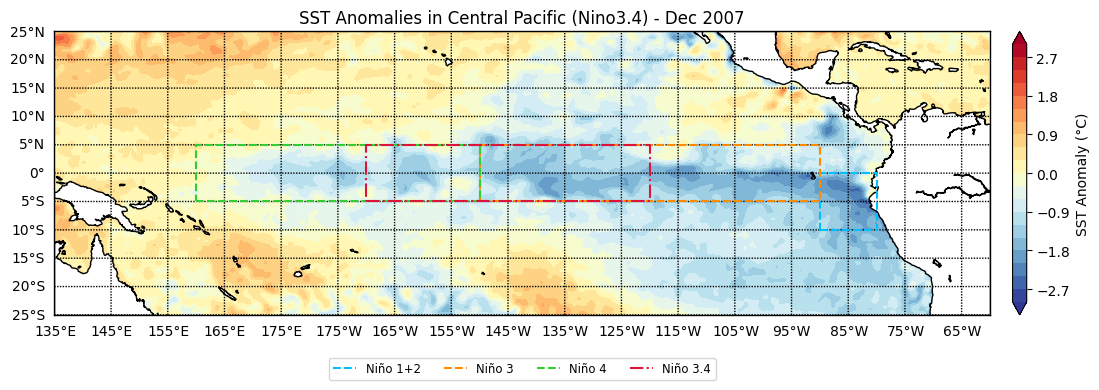

In [ ]:
plot_ssta_grid(grid, pd.to_datetime(start), lon0, lon1+360, lat0, lat1)

In [ ]:
# Function to get Niño 3.4 SST anomalies from NOAA data
def get_nino34_anomalies(start="1950", end="2025"):
    url = "https://psl.noaa.gov/data/timeseries/month/data/nino34.long.anom.data"
    response = requests.get(url, timeout=30)
    lines = response.text.strip().split('\n')[1:]  # skip header

    data = []
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 13:
            continue
        try:
            year = int(parts[0])
            if year < int(start[:4]) or year > int(end[:4]):
                continue
            for i, val in enumerate(parts[1:13]):
                if '-99.99' in val:
                    break
                ts = pd.Timestamp(year=year, month=i + 1, day=15)
                data.append((ts, float(val)))
        except ValueError:
            continue

    return pd.DataFrame(data, columns=["date", "ssta"]).set_index("date")

ssta = get_nino34_anomalies("1950", "2025")
print(ssta.head())

            ssta
date            
1950-01-15 -1.05
1950-02-15 -1.50
1950-03-15 -1.07
1950-04-15 -0.91
1950-05-15 -1.30


In [ ]:
# Refer to https://www.nature.com/articles/s41598-018-38034-z
# Global Disease Outbreaks Associated with the 2015–2016 El Niño Event
# To digitize the Fig.4g and get data: https://github.com/cywhale/marineheatwave/blob/main/API/dev/examples/digitize_plot01.py
# Load the Tanzania cholera data
cholera_df = pd.read_csv('./data/examples/tanzania_cholera_detrended.csv')
print(cholera_df) #It's yearly data!

    year  detrended_cholera_cases
0   2000             -2111.111111
1   2001             -5068.376068
2   2002              4801.975802
3   2003             -5337.218337
4   2004              3572.982573
5   2005             -3071.262071
6   2006              7451.992452
7   2007             -4069.819070
8   2008             -2764.013764
9   2009              1767.898768
10  2010             -1035.742036
11  2011             -4185.037185
12  2012             -4722.721723
13  2013             -4607.503608
14  2014             -4722.721723
15  2015              5838.938839
16  2016              5915.750916
17  2017               116.439116


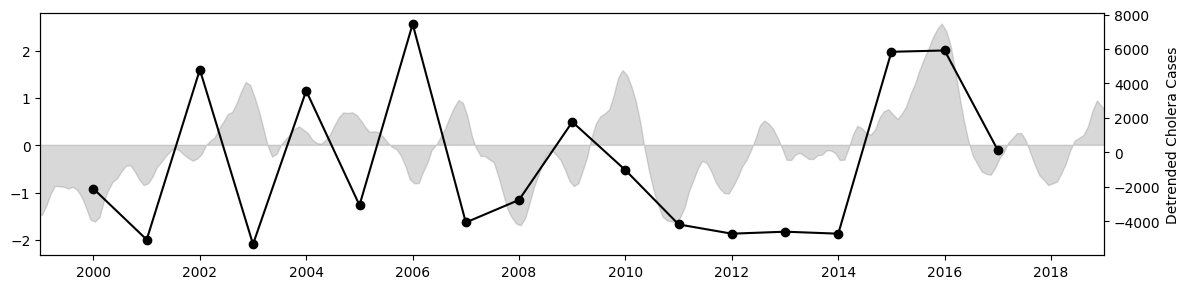

In [ ]:
oni = ssta['ssta'].rolling(window=3, center=True).mean()

# Plotting
fig, ax1 = plt.subplots(figsize=(12, 3))

# 1. Gray shaded full ONI curve
ax1.fill_between(oni.index, oni, 0, color='gray', alpha=0.3, label='ONI 3mo mean')

# 2. Cholera annual points at mid-year
ax2 = ax1.twinx()
cholera_dates = pd.to_datetime(cholera_df["year"].astype(str))
ax2.set_xlim(pd.Timestamp("1999-01-01"), pd.Timestamp("2018-12-31"))
ax2.plot(cholera_dates, cholera_df["detrended_cholera_cases"], 'ko-', label='Cholera Cases')
ax2.set_ylabel("Detrended Cholera Cases")
fig.tight_layout()

In [ ]:
# Determine El Niño / La Niña years using ONI following NOAA criteria
# Following https://origin.cpc.ncep.noaa.gov/products/analysis_monitoring/ensostuff/ONI_v5.php
def classify_enso_events(df, min_months=5, threshold=0.5):
    df = df.copy()
    df['oni_3mo'] = df['ssta'].rolling(window=3, center=True).mean()

    def phase_classify(x):
        if x >= threshold:
            return "El Niño"
        elif x <= -threshold:
            return "La Niña"
        else:
            return "Neutral"

    df['phase'] = df['oni_3mo'].apply(phase_classify)

    # Identify runs of El Niño or La Niña
    df['group'] = (df['phase'] != df['phase'].shift()).cumsum()
    grouped = df.groupby('group')

    result = []
    for _, g in grouped:
        phase = g['phase'].iloc[0]
        if phase in ['El Niño', 'La Niña'] and len(g) >= min_months:
            start = g.index[0]
            end = g.index[-1]
            peak_ONI = g['oni_3mo'].max() if phase == 'El Niño' else g['oni_3mo'].min()
            result.append({
                'start': start,
                'end': end,
                'phase': phase,
                'peak_ONI': peak_ONI
            })

    return pd.DataFrame(result)

enso_phase = classify_enso_events(ssta)
print(enso_phase.head())

       start        end    phase  peak_ONI
0 1950-02-15 1951-03-15  La Niña -1.206667
1 1951-08-15 1951-12-15  El Niño  0.786667
2 1954-05-15 1956-12-15  La Niña -1.673333
3 1957-06-15 1958-04-15  El Niño  1.373333
4 1963-07-15 1964-01-15  El Niño  0.880000


In [ ]:
def plot_enso_timeseries_bar(ssta: pd.DataFrame,
                             enso_events: pd.DataFrame):
    # import matplotlib.pyplot as plt
    # import matplotlib.dates as mdates
    # 展平 ENSO 事件為每月資料
    enso_long = []
    for _, row in enso_events.iterrows():
        period = pd.date_range(start=row["start"], end=row["end"], freq="MS")
        for date in period:
            enso_long.append({
                "date": date.replace(day=15),
                "phase": row["phase"]
            })
    enso_long = pd.DataFrame(enso_long)
    enso_long.set_index("date", inplace=True)

    # 加入 SSTA 值
    enso_long = enso_long.join(ssta)

    # 建立 bar 資料
    enso_colors = []
    enso_bar_values = []
    for _, row in enso_long.iterrows():
        val = row['ssta']
        if row['phase'] == "El Niño":
            enso_colors.append('#f8766d')
            enso_bar_values.append(val)
        elif row['phase'] == "La Niña":
            enso_colors.append('#619cff')
            enso_bar_values.append(val)  # 負值顯示向下
        else:
            enso_colors.append('lightgray')
            enso_bar_values.append(0)

    # 建立圖表
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                             gridspec_kw={'height_ratios': [1.2, 1]})

    # Plot 1: Niño 3.4 SSTA
    axes[0].plot(ssta.index, ssta['ssta'], color='cornflowerblue', lw=1, label="Niño 3.4 SSTA")
    axes[0].axhline(y=0.5, linestyle="dotted", linewidth=0.5, color="red", label="El Niño")
    axes[0].axhline(y=-0.5, linestyle="dotted", linewidth=0.5, color="blue", label="La Niña")
    axes[0].set_ylabel("SST Anomaly (°C)")
    axes[0].legend(loc='upper left')
    axes[0].axhline(0, color='black', linewidth=0.5)

    # Plot 2: ENSO Events
    axes[1].bar(enso_long.index, enso_bar_values, color=enso_colors, width=20)
    axes[1].axhline(y=1.5, linestyle="--", linewidth=0.5, color="red", label="Strong El Niño")
    axes[1].axhline(y=-1.5, linestyle="--", linewidth=0.5, color="blue", label="Strong La Niña")
    axes[1].set_ylabel("ENSO Phase\n(Bar ~ SSTA)")
    axes[1].set_ylim(-2.5, 2.5)
    axes[1].legend(loc='upper left')

    # X-axis formatting
    axes[-1].xaxis.set_major_locator(mdates.YearLocator(5))
    axes[-1].xaxis.set_minor_locator(mdates.YearLocator(1))
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    axes[-1].grid(True, axis='x', which='major', linestyle='--', alpha=0.3)

    plt.suptitle("ENSO Time Series: Niño 3.4 SSTA and ENSO events", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

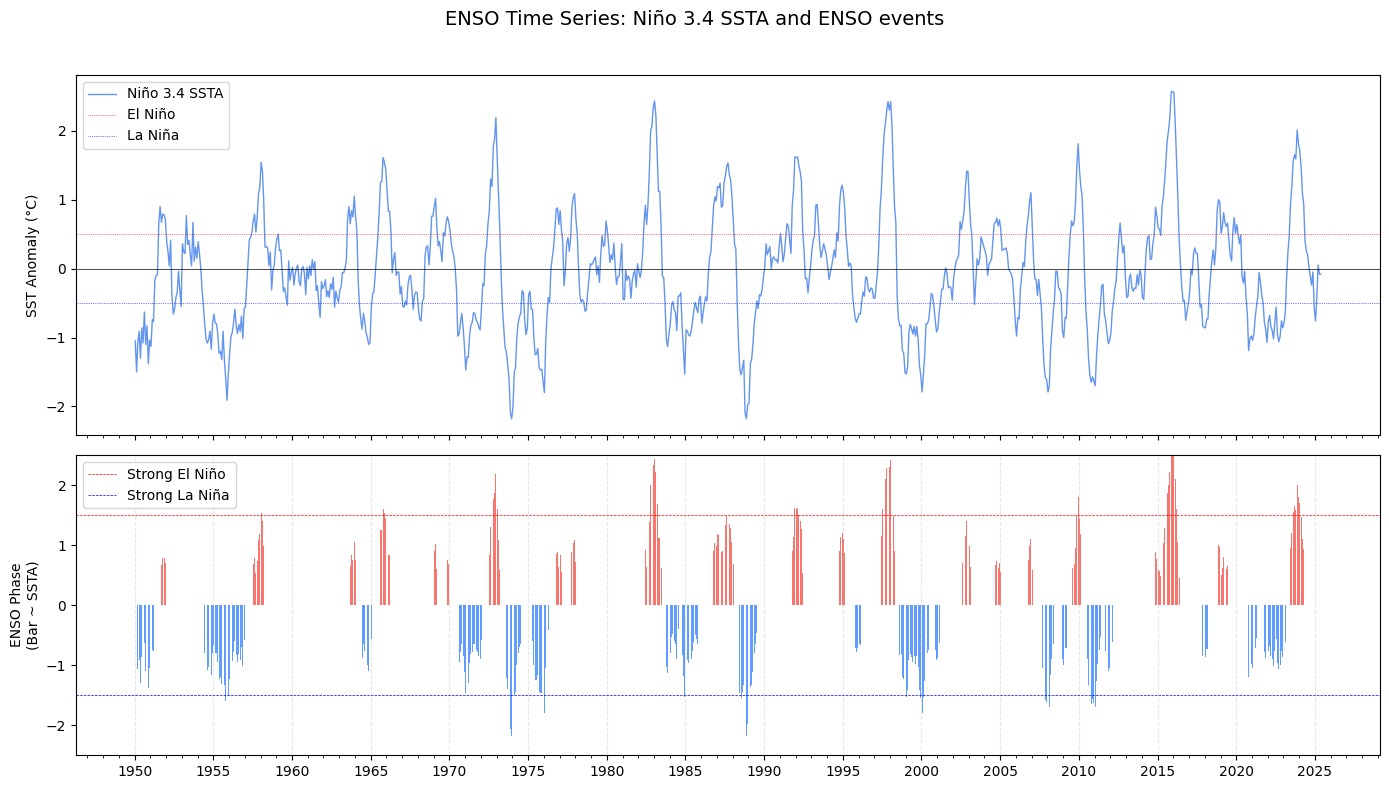

In [ ]:
plot_enso_timeseries_bar(ssta, enso_phase)

In [ ]:
# 1. 原始 Niño 3.4 SST 異常, the same as ssta
nino_df = get_nino34_anomalies()
nino_df["oni_3mo"] = nino_df["ssta"].rolling(3, center=True).mean()

events_df = classify_enso_events(nino_df)

# ---------- Create a monthly phase series ----------
phase_series = pd.Series("Neutral", index=nino_df.index)
for _, row in events_df.iterrows():
    phase_series.loc[row["start"]:row["end"]] = row["phase"]

# ---------- Build annual DJF table (1999-12/2000-02 etc.) ----------
# Trick: how you treat ENSO events (DJF) as this year's phase or next year's phase
rows = []
for yr in range(1999, 2017):  # target cholera years
    months = [pd.Timestamp(yr, 12, 15),  # try range(2000, 2018) and yr-1, yr, totally different results!
              pd.Timestamp(yr+1, 1, 15),
              pd.Timestamp(yr+1, 2, 15)]
    oni_vals = nino_df.loc[months, "oni_3mo"].values
    djf_mean = float(pd.Series(oni_vals).mean())
    phases = phase_series.loc[months].unique()
    # Determine yearly phase: prefer El/La if present
    if "El Niño" in phases:
        y_phase = "El Niño"
    elif "La Niña" in phases:
        y_phase = "La Niña"
    else:
        y_phase = "Neutral"
    rows.append({"year": yr, "oni_djf": djf_mean, "enso_phase": y_phase})

df_djf = pd.DataFrame(rows)
merged_df = cholera_df.merge(df_djf, on="year", how="left")
print(merged_df)

    year  detrended_cholera_cases   oni_djf enso_phase
0   2000             -2111.111111 -0.774444    La Niña
1   2001             -5068.376068 -0.167778    Neutral
2   2002              4801.975802  0.992222    El Niño
3   2003             -5337.218337  0.227778    Neutral
4   2004              3572.982573  0.502222    El Niño
5   2005             -3071.262071 -0.781111    Neutral
6   2006              7451.992452  0.560000    El Niño
7   2007             -4069.819070 -1.637778    La Niña
8   2008             -2764.013764 -0.812222    La Niña
9   2009              1767.898768  1.425556    El Niño
10  2010             -1035.742036 -1.492222    La Niña
11  2011             -4185.037185 -0.853333    La Niña
12  2012             -4722.721723 -0.236667    Neutral
13  2013             -4607.503608 -0.270000    Neutral
14  2014             -4722.721723  0.646667    El Niño
15  2015              5838.938839  2.354444    El Niño
16  2016              5915.750916 -0.308889    Neutral
17  2017  

enso_phase
El Niño    6
La Niña    5
Neutral    6
dtype: int64


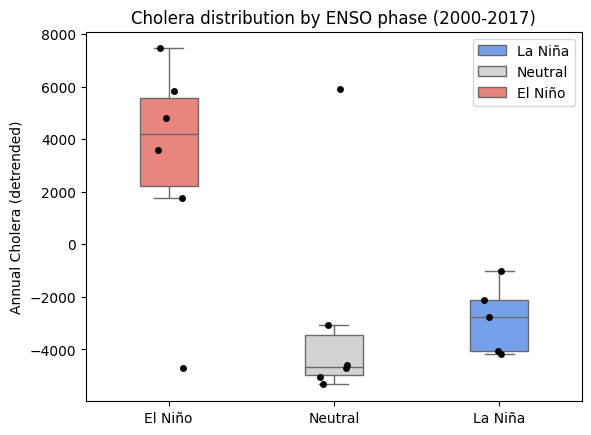

In [ ]:
# import seaborn as sns, matplotlib.pyplot as plt
# 分組樣本數
print(merged_df.groupby('enso_phase').size())
sns.axes_style()
sns.boxplot(data=merged_df, x='enso_phase', y='detrended_cholera_cases',
            order=['El Niño','Neutral','La Niña'],
            showfliers=False, width=0.35, hue='enso_phase',
            palette={'El Niño':'#f8766d','La Niña':'#619cff','Neutral':'lightgray'})
sns.stripplot(data=merged_df, x='enso_phase', y='detrended_cholera_cases',
              order=['El Niño','Neutral','La Niña'],
              color='black', jitter=0.1)
plt.ylabel('Annual Cholera (detrended)'); plt.xlabel('')
plt.title('Cholera distribution by ENSO phase (2000-2017)')
plt.show()


In [ ]:
def plot_cholera_vs_enso(cholera_df, nino_df, events_df):
    # import matplotlib.pyplot as plt
    # Prepare ONI 3-month moving average (masked/clean)
    oni = nino_df['ssta'].rolling(window=3, center=True).mean().dropna().astype(float)

    # Flatten ENSO events into monthly records for bar heights
    enso_long = []
    for _, row in events_df.iterrows():
        period = pd.date_range(start=row["start"], end=row["end"], freq="MS")
        for date in period:
            enso_long.append({"date": date.replace(day=15), "phase": row["phase"]})
    enso_long = pd.DataFrame(enso_long).set_index("date")
    enso_long = enso_long.join(nino_df["ssta"], how="left")

    # Determine colors and bar heights
    enso_colors = []
    enso_bar_values = []
    for _, row in enso_long.iterrows():
        val = row['ssta']
        if row['phase'] == "El Niño":
            enso_colors.append('#f8766d')
            enso_bar_values.append(val)
        elif row['phase'] == "La Niña":
            enso_colors.append('#619cff')
            enso_bar_values.append(val)
        else:
            # neutral — optional: lightgray or zero height
            enso_colors.append('lightgray')
            enso_bar_values.append(0)

    # Plotting
    fig, ax1 = plt.subplots(figsize=(12, 3))

    # 1. Gray shaded full ONI curve
    ax1.fill_between(oni.index, oni, 0, color='gray', alpha=0.3, label='ONI 3mo mean')

    # 2. Red/blue bars for ENSO months
    ax1.bar(enso_long.index, enso_bar_values, width=20, color=enso_colors, alpha=0.7, label='ENSO anomaly')

    # 3. Trick: Cholera annual points at end of the year (Oct, before DJF events)
    ax2 = ax1.twinx()
    cholera_dates = pd.to_datetime(cholera_df["year"].astype(str)) + pd.DateOffset(months=10, days=15)
    ax2.plot(cholera_dates, cholera_df["detrended_cholera_cases"], 'ko-', label='Cholera Cases')
    ax2.set_ylabel("Detrended Cholera Cases")

    # 4. Optional: DJF ONI dashed line
    if "oni_djf" in cholera_df.columns:
        ax2.plot(cholera_dates, cholera_df["oni_djf"] * 1000, 'k--', alpha=0.5, label="DJF ONI ×1000")

    # Labels, limits, legends
    ax1.set_ylabel("Niño 3.4 SSTA (°C)")
    ax1.set_xlim(pd.Timestamp("1999-01-01"), pd.Timestamp("2018-12-31"))
    ax1.set_title("Tanzania Cholera vs Monthly ONI & ENSO Anomalies (bars)")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    plt.tight_layout()
    plt.show()


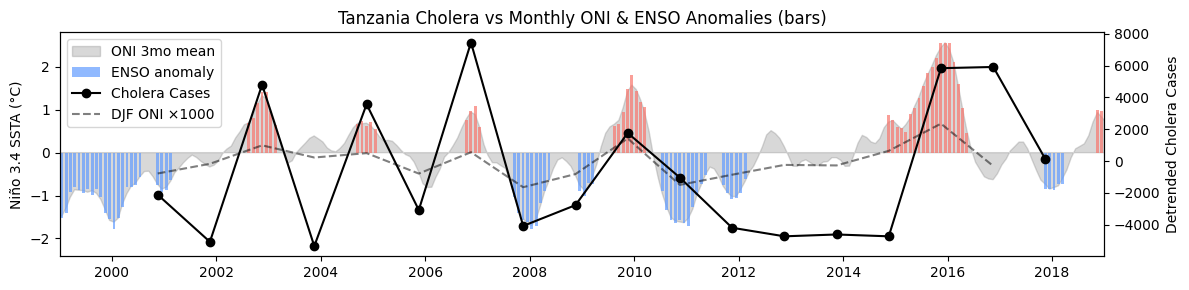

In [ ]:
plot_cholera_vs_enso(merged_df, nino_df, events_df)

STL Decomposition

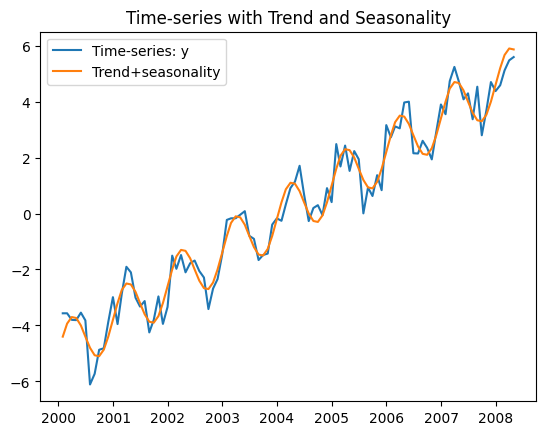

In [ ]:
# 1. Simulate trend + seasonality + noise
np.random.seed(2024)
n = 100
t = np.arange(1, n+1)
time_index = pd.date_range("2000-01-01", periods=n, freq="ME")

mu = -5 + 0.1 * t                # 線性趨勢
ss = np.sin(2 * np.pi * t / 12)        # 每 12 期的季節性
e = 0.5 * np.random.randn(n)            # 隨機噪音
y = mu + ss + e

df = pd.DataFrame({"y": y, "signal": mu + ss}, index=time_index)

plt.figure()
plt.plot(df.index, df["y"], label="Time-series: y")
plt.plot(df.index, df["signal"], label="Trend+seasonality")
plt.legend()
plt.title("Time-series with Trend and Seasonality");

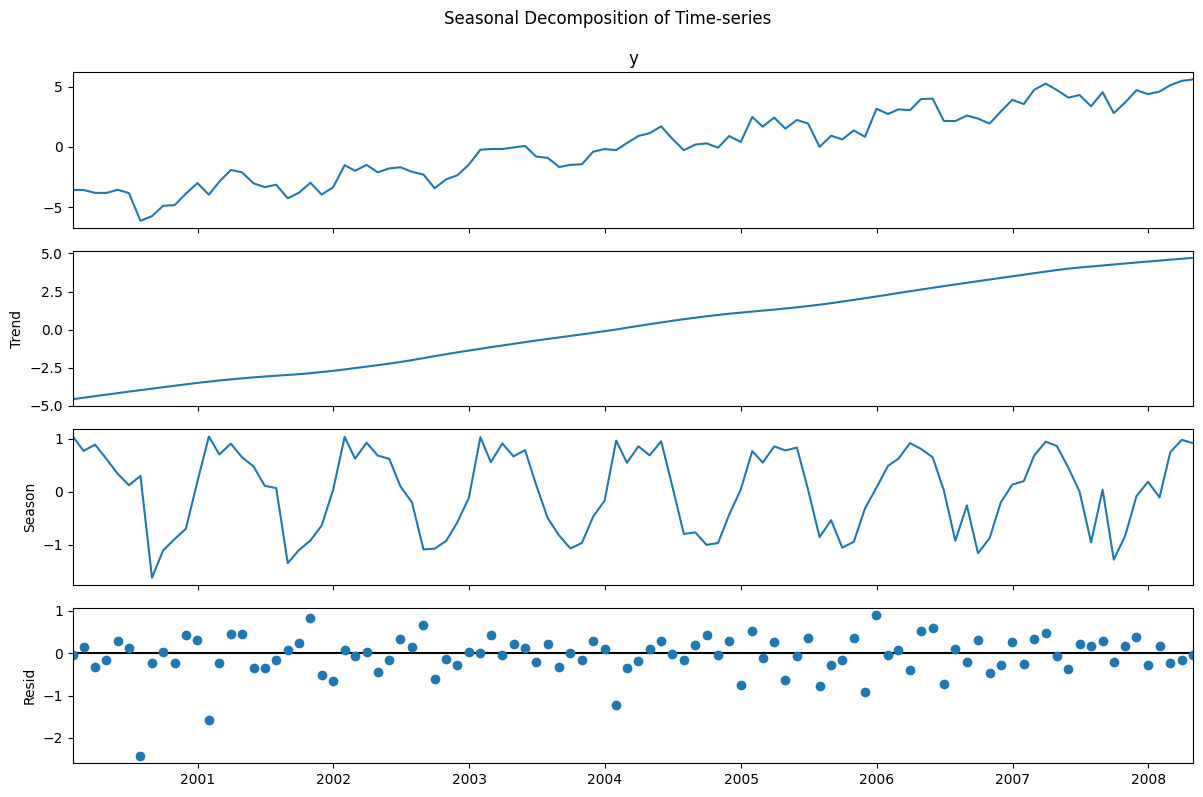

In [ ]:
# from statsmodels.tsa.seasonal import STL
stl = STL(df["y"],
          period=12,
          robust=True).fit()
fig = stl.plot()
fig.set_size_inches(12, 8)
fig.suptitle(f"Seasonal Decomposition of Time-series", y=0.99)
plt.tight_layout()


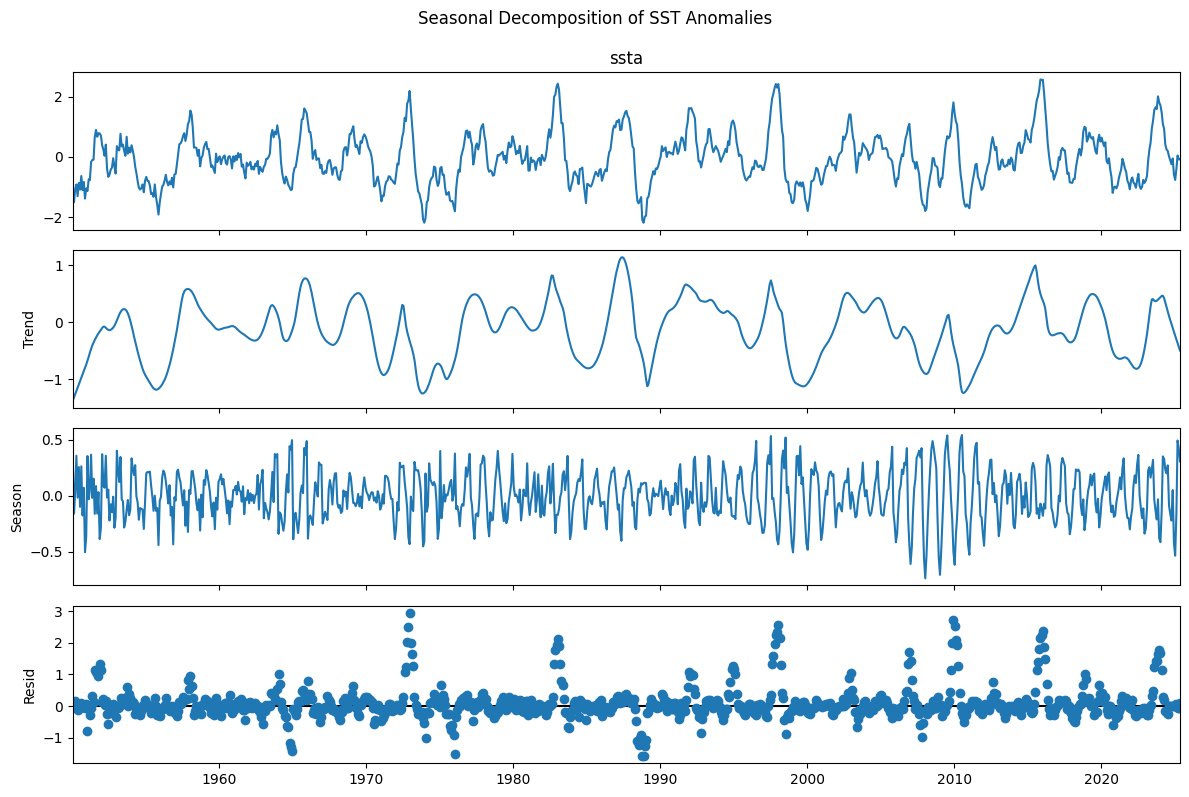

In [ ]:
stla = STL(ssta["ssta"], period=12, robust=True).fit()
fig = stla.plot()
fig.set_size_inches(12, 8)
fig.suptitle(f"Seasonal Decomposition of SST Anomalies", y=0.99)
plt.tight_layout()

氣象浮標